# Lifestyle Habits & Fitness Performance Analysis


**Author:** Ajao Basit Ololade


**Tool:** Python (Jupyter Notebook)


**Data:** 59 respondents — Primary Survey Data, June 2026



> **Note:** This is a live dataset. Response figures reflect submissions collected as of june 2026 and will be updated as new responses are received.

In [1]:
# Import libraries needed for analysis

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [2]:
# Step 1: Load the dataset into Python and preview the first 5 rows

df = pd.read_excel('Lifestyle Habits  Fitness Performance.xlsx')
df.head()


,Index,Submitted Time,Time Spent,Collector,Collector Details,IP Address,1. What is your gender?,2. What is your age group?,3. How often do you go to the gym?,4. What is your primary fitness goal?,5. How many hours do you sleep on average per night?,6. What best describes your smoking status?,"7. If you currently or previously smoked, which products have you used?",8. How often do you currently use smoking or vaping products,9. How would you rate your cardiovascular endurance?,10. How would you rate your recovery between workouts?,11. How would you rate your overall gym performance?,12. Do you believe smoking or vaping affects fitness performance?,13. Would you consider quitting smoking or vaping if it was negatively affecting your fitness goals?,14. Any additional comments?
0,1,2026-06-08 21:12:22 (UTC+01:00) West Africa St...,74s,Link,(Empty),102.89.84.196(Lagos/Lagos/Nigeria),Male,18–24,5–6 times per week,Build muscle,(Skip),Never smoked,I have never used any smoking or vaping products,Not applicable,8,9,7,"Yes, negatively",Not applicable,(Empty)
1,2,2026-06-08 22:07:41 (UTC+01:00) West Africa St...,692s,Link,(Empty),102.89.76.157(Lagos/Lagos/Nigeria),Male,18–24,1–2 times per week,Lose fat,5-6 hours,Never smoked,I have never used any smoking or vaping products,Not applicable,4,4,3,"Yes, positively",Not applicable,(Empty)
2,3,2026-06-08 22:23:05 (UTC+01:00) West Africa St...,111s,Link,(Empty),102.93.8.152(Lagos/Lagos/Nigeria),Male,18–24,5–6 times per week,Build muscle,7-8 hours,Never smoked,Vape / E-cigarettes,Not applicable,6,4,7,"Yes, negatively",Yes,(Empty)
3,4,2026-06-08 23:02:16 (UTC+01:00) West Africa St...,113s,Link,(Empty),102.93.10.214(Lagos/Lagos/Nigeria),Male,18–24,Daily,Athletic performance,7-8 hours,Never smoked,I have never used any smoking or vaping products,Not applicable,8,7,10,"Yes, positively",Yes,(Empty)
4,5,2026-06-08 23:08:13 (UTC+01:00) West Africa St...,49s,Link,(Empty),102.93.13.36(Lagos/Lagos/Nigeria),Male,18–24,1–2 times per week,Build muscle,7-8 hours,Current smoker,Weed (Cannabis),Occasionally,8,10,10,"Yes, negatively",Yes,N


In [3]:
# Check exact column names before renaming to avoid KeyError mistakes

df.columns.tolist()

['Index',
 'Submitted Time',
 'Time Spent',
 'Collector',
 'Collector Details',
 'IP Address',
 '1. What is your gender?',
 '2. What is your age group?',
 '3. How often do you go to the gym?',
 '4. What is your primary fitness goal?',
 '5. How many hours do you sleep on average per night?',
 '6. What best describes your smoking status?',
 '7. If you currently or previously smoked, which products have you used?',
 '8. How often do you currently use smoking or vaping products',
 '9. How would you rate your cardiovascular endurance?',
 '10. How would you rate your recovery between workouts?',
 '11. How would you rate your overall gym performance?',
 '12. Do you believe smoking or vaping affects fitness performance?',
 '13. Would you consider quitting smoking or vaping if it was negatively affecting your fitness goals?',
 '14. Any additional comments?']

In [4]:
# Drop metadata columns not needed for analysis

df = df.drop(columns=[
    'Index', 
    '8. How often do you currently use smoking or vaping products',
    '14. Any additional comments?'
])
df.head()

,Submitted Time,Time Spent,Collector,Collector Details,IP Address,1. What is your gender?,2. What is your age group?,3. How often do you go to the gym?,4. What is your primary fitness goal?,5. How many hours do you sleep on average per night?,6. What best describes your smoking status?,"7. If you currently or previously smoked, which products have you used?",9. How would you rate your cardiovascular endurance?,10. How would you rate your recovery between workouts?,11. How would you rate your overall gym performance?,12. Do you believe smoking or vaping affects fitness performance?,13. Would you consider quitting smoking or vaping if it was negatively affecting your fitness goals?
0,2026-06-08 21:12:22 (UTC+01:00) West Africa St...,74s,Link,(Empty),102.89.84.196(Lagos/Lagos/Nigeria),Male,18–24,5–6 times per week,Build muscle,(Skip),Never smoked,I have never used any smoking or vaping products,8,9,7,"Yes, negatively",Not applicable
1,2026-06-08 22:07:41 (UTC+01:00) West Africa St...,692s,Link,(Empty),102.89.76.157(Lagos/Lagos/Nigeria),Male,18–24,1–2 times per week,Lose fat,5-6 hours,Never smoked,I have never used any smoking or vaping products,4,4,3,"Yes, positively",Not applicable
2,2026-06-08 22:23:05 (UTC+01:00) West Africa St...,111s,Link,(Empty),102.93.8.152(Lagos/Lagos/Nigeria),Male,18–24,5–6 times per week,Build muscle,7-8 hours,Never smoked,Vape / E-cigarettes,6,4,7,"Yes, negatively",Yes
3,2026-06-08 23:02:16 (UTC+01:00) West Africa St...,113s,Link,(Empty),102.93.10.214(Lagos/Lagos/Nigeria),Male,18–24,Daily,Athletic performance,7-8 hours,Never smoked,I have never used any smoking or vaping products,8,7,10,"Yes, positively",Yes
4,2026-06-08 23:08:13 (UTC+01:00) West Africa St...,49s,Link,(Empty),102.93.13.36(Lagos/Lagos/Nigeria),Male,18–24,1–2 times per week,Build muscle,7-8 hours,Current smoker,Weed (Cannabis),8,10,10,"Yes, negatively",Yes


In [5]:
# Rename columns to shorter, cleaner names for easier analysis

df = df.iloc[:, 5:]
df.columns = [
    'gender', 'age_group', 'gym_frequency', 'fitness_goal',
    'sleep_hours', 'smoking_status', 'smoking_products',
    'cardio_rating', 'recovery_rating','performance_rating',
    'smoking_affects_fitness', 'would_quit_smoking'
]

df.head()
 

,gender,age_group,gym_frequency,fitness_goal,sleep_hours,smoking_status,smoking_products,cardio_rating,recovery_rating,performance_rating,smoking_affects_fitness,would_quit_smoking
0,Male,18–24,5–6 times per week,Build muscle,(Skip),Never smoked,I have never used any smoking or vaping products,8,9,7,"Yes, negatively",Not applicable
1,Male,18–24,1–2 times per week,Lose fat,5-6 hours,Never smoked,I have never used any smoking or vaping products,4,4,3,"Yes, positively",Not applicable
2,Male,18–24,5–6 times per week,Build muscle,7-8 hours,Never smoked,Vape / E-cigarettes,6,4,7,"Yes, negatively",Yes
3,Male,18–24,Daily,Athletic performance,7-8 hours,Never smoked,I have never used any smoking or vaping products,8,7,10,"Yes, positively",Yes
4,Male,18–24,1–2 times per week,Build muscle,7-8 hours,Current smoker,Weed (Cannabis),8,10,10,"Yes, negatively",Yes


## Exploratory Data Analysis
Univariate distributions for all 12 variables across 59 respondents.

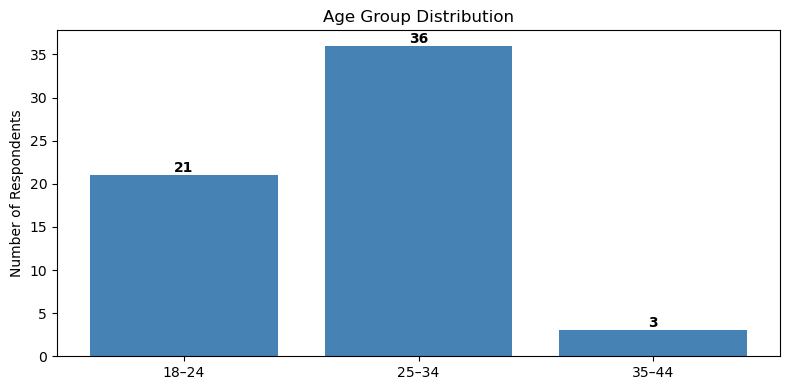

In [6]:
# Age group distribution — sorted alphabetically

age_counts = df['age_group'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(age_counts.index, age_counts.values, color='steelblue')

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Age Group Distribution')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

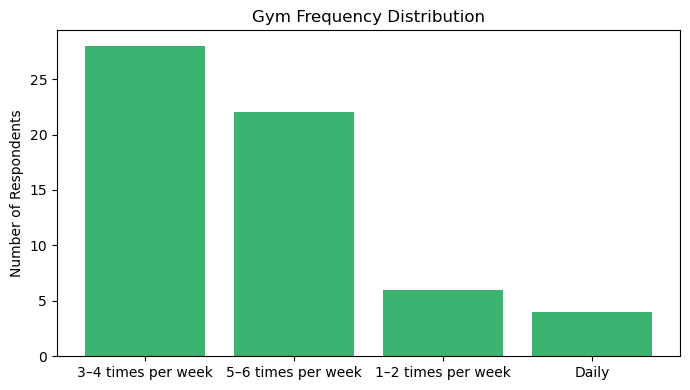

In [7]:
# Gym frequency distribution

gym_counts = df['gym_frequency'].value_counts()

# Plot

plt.figure(figsize=(7, 4))
plt.bar(gym_counts.index, gym_counts.values, color='mediumseagreen')

plt.title('Gym Frequency Distribution')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

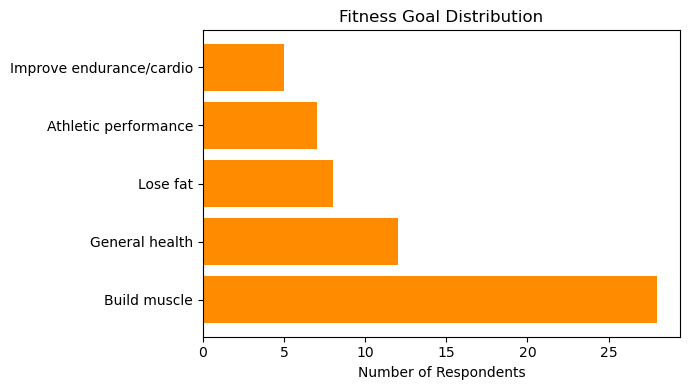

In [8]:
# Plot fitness goal distribution — horizontal bar chart

goal_counts = df['fitness_goal'].value_counts()

# Plot

plt.figure(figsize=(7, 4))
plt.barh(range(len(goal_counts)), goal_counts.values, color='darkorange')

plt.title('Fitness Goal Distribution')

plt.xlabel('Number of Respondents')
plt.yticks(range(len(goal_counts)), goal_counts.index)

plt.tight_layout()
plt.show()

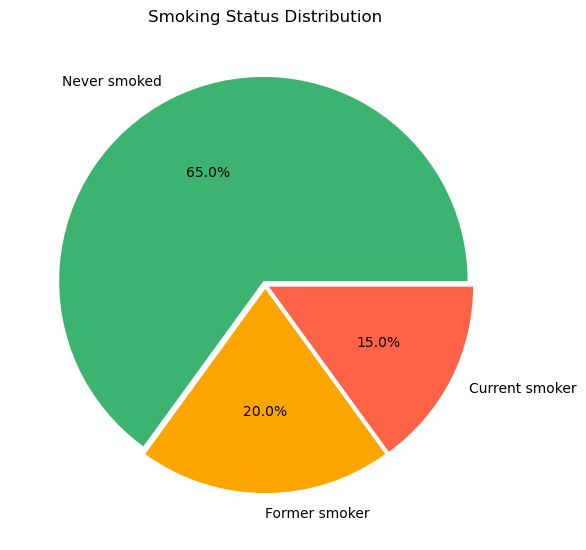

In [9]:
# Plot smoking status distribution — donut chart

smoking_counts = df['smoking_status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    smoking_counts.values,
    labels=smoking_counts.index,
    colors=['mediumseagreen', 'orange', 'tomato'],
    autopct='%1.1f%%',
    explode=(0.02, 0.02, 0.02)
)

plt.title('Smoking Status Distribution')
plt.tight_layout()
plt.show()

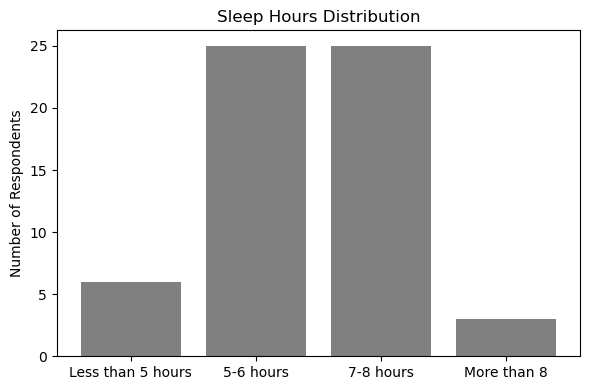

In [10]:
# Plot sleep hours distribution

sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8']
sleep_counts = df['sleep_hours'].value_counts(dropna=True)
sleep_counts = sleep_counts.reindex(sleep_order)

plt.figure(figsize=(6, 4))
plt.bar(range(len(sleep_counts)), sleep_counts.values, color='grey')

plt.title('Sleep Hours Distribution')
plt.ylabel('Number of Respondents')
plt.xticks(range(len(sleep_counts)), sleep_counts.index)

plt.tight_layout()
plt.show()

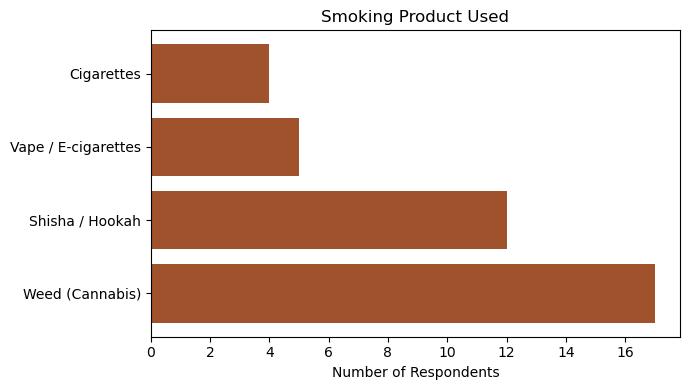

In [11]:
# Split multi-select responses using the ┋ separator and plot smoking products used

raw = df['smoking_products'].dropna()

# Split multi-select responses by the ┋ separator
split = raw.str.split('┋').explode()
split = split.str.strip()

# Remove 'never used' responses — only plot actual product usage

split = split[split != 'I have never used any smoking or vaping products']

product_counts = split.value_counts()

plt.figure(figsize=(7, 4))
plt.barh(range(len(product_counts)), product_counts.values, color='sienna')
plt.title('Smoking Product Used')
plt.xlabel('Number of Respondents')
plt.yticks(range(len(product_counts)), product_counts.index)
plt.tight_layout()
plt.show()

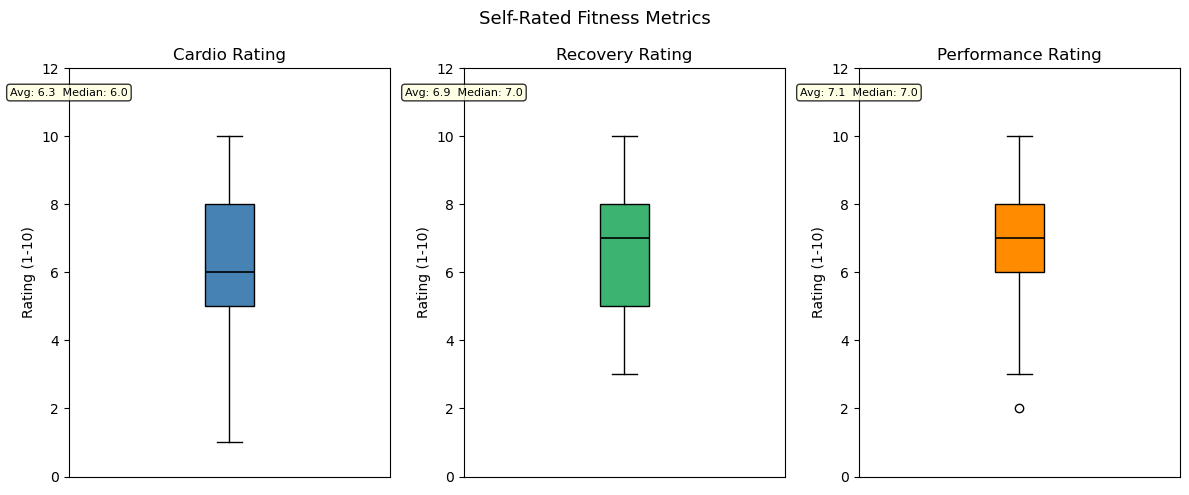

In [12]:
# Plot self-rated fitness metrics — cardio, recovery, and performance

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

data = [
    df['cardio_rating'].dropna(),
    df['recovery_rating'].dropna(),
    df['performance_rating'].dropna()
]
titles = ['Cardio Rating', 'Recovery Rating', 'Performance Rating']
colors = ['steelblue', 'mediumseagreen', 'darkorange']

for i, (value, title, color) in enumerate(zip(data, titles, colors)):
    bp = axes[i].boxplot(value, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)
    
    axes[i].set_title(title)
    axes[i].set_ylabel('Rating (1-10)')
    axes[i].set_ylim(0, 12)
    axes[i].set_xticks([])

    mean_val = round(value.mean(), 1)
    median_val = round(value.median(), 1)
    axes[i].text(0.5, 11.2,
                 f'Avg: {mean_val}  Median: {median_val}',
                 fontsize=8, ha='center', color='black',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Self-Rated Fitness Metrics', fontsize=13)
plt.tight_layout()
plt.show()



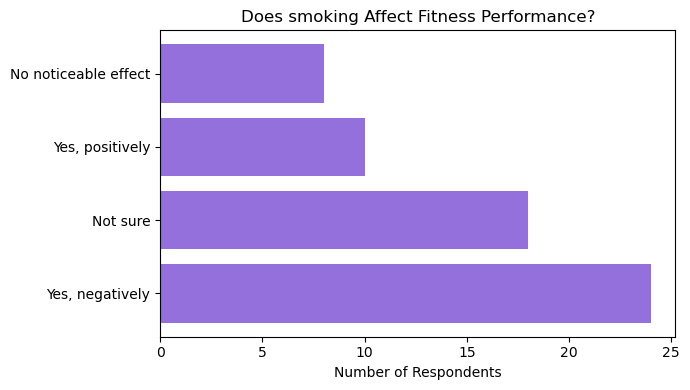

In [13]:
# Plot responses to: does smoking affect fitness performance?

affects_counts = df['smoking_affects_fitness'].value_counts()

plt.figure(figsize=(7, 4))
plt.barh(range(len(affects_counts)),affects_counts.values, color='mediumpurple')

plt.title('Does smoking Affect Fitness Performance?')
plt.xlabel('Number of Respondents')
plt.yticks(range(len(affects_counts)), affects_counts.index)

plt.tight_layout()
plt.show()
    
         

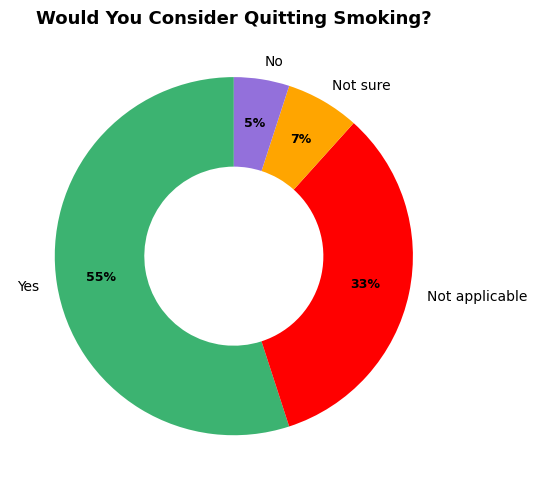

In [14]:
# Plot responses to: would you consider quitting smoking?

quit_counts = df['would_quit_smoking'].value_counts(dropna=True)

labels = quit_counts.index.tolist()
sizes = quit_counts.values.tolist()
colors = ['mediumseagreen', 'red', 'orange', 'mediumpurple']


# Colour mapping: Yes = green, No = red, Not sure = purple, Not applicable = grey

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)  # donut hole
)

for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')


ax.set_title('Would You Consider Quitting Smoking?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cross-Variable Analysis
Grouped comparisons and heatmaps examining relationships between lifestyle habits and fitness outcomes.

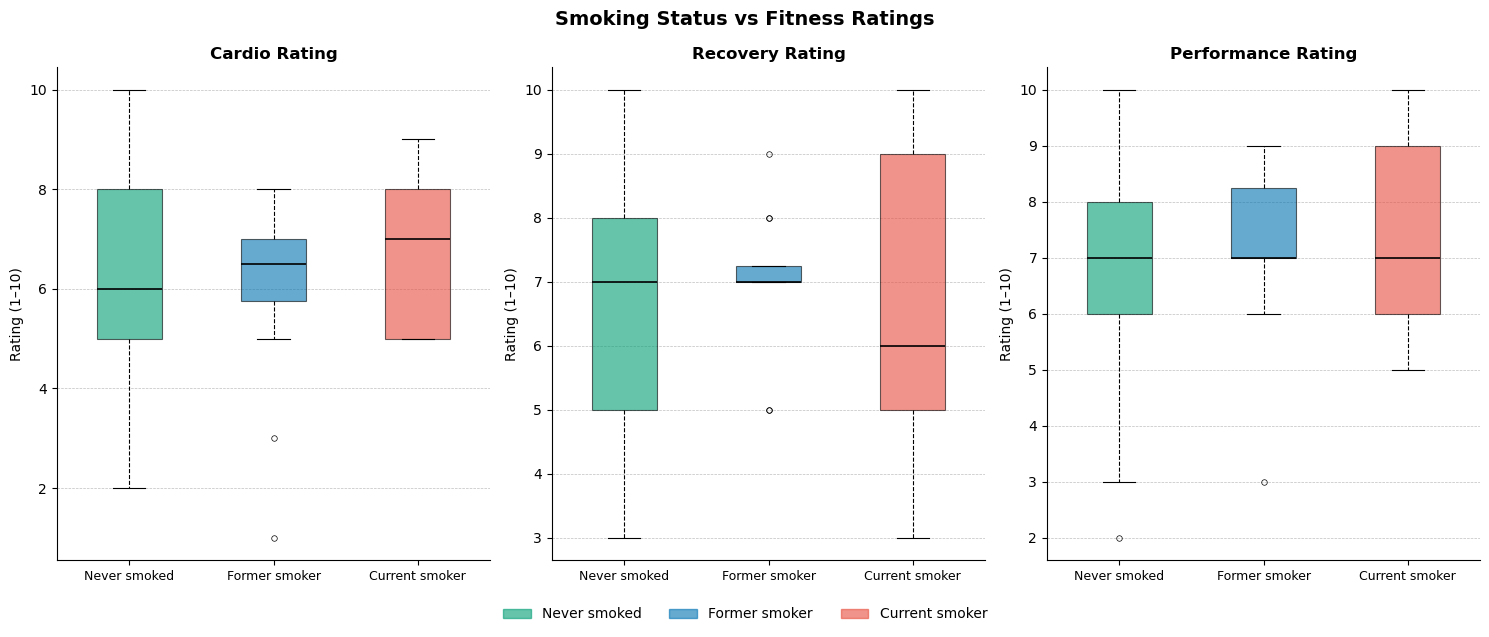

In [15]:
# Smoking status vs self-rated fitness metrics — grouped box plots

smoking_groups = ['Never smoked', 'Former smoker', 'Current smoker']

smoke_colors = {
    'Never smoked': '#009E73',
    'Former smoker': '#0072B2',
    'Current smoker': '#E74C3C'
}

ratings = ['cardio_rating', 'recovery_rating', 'performance_rating']
titles = ['Cardio Rating', 'Recovery Rating', 'Performance Rating']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, col, title in zip(axes, ratings, titles):
    data_by_group = [
        df[df['smoking_status'] == grp][col].dropna().values
        for grp in smoking_groups
    ]
    bp = ax.boxplot(data_by_group, patch_artist=True, widths=0.45,
                    boxprops=dict(linewidth=0.8),
                    whiskerprops=dict(linewidth=0.8, linestyle='--'),
                    capprops=dict(linewidth=0.8),
                    flierprops=dict(marker='o', markersize=4, linestyle='none',
                                   markeredgewidth=0.5))
    
    for patch, grp in zip(bp['boxes'], smoking_groups):
        patch.set_facecolor(smoke_colors[grp])
        patch.set_alpha(0.6)   # lighter fill
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Never smoked', 'Former smoker', 'Current smoker'], fontsize=9)
    ax.set_ylabel('Rating (1–10)', fontsize=10)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='grey')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)  # cleaner frame

legend_patches = [mpatches.Patch(color=smoke_colors[g], alpha=0.6, label=g) for g in smoking_groups]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.06), frameon=False)

fig.suptitle('Smoking Status vs Fitness Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("smoking_vs_cardio.png", dpi=150, bbox_inches="tight")
plt.show()


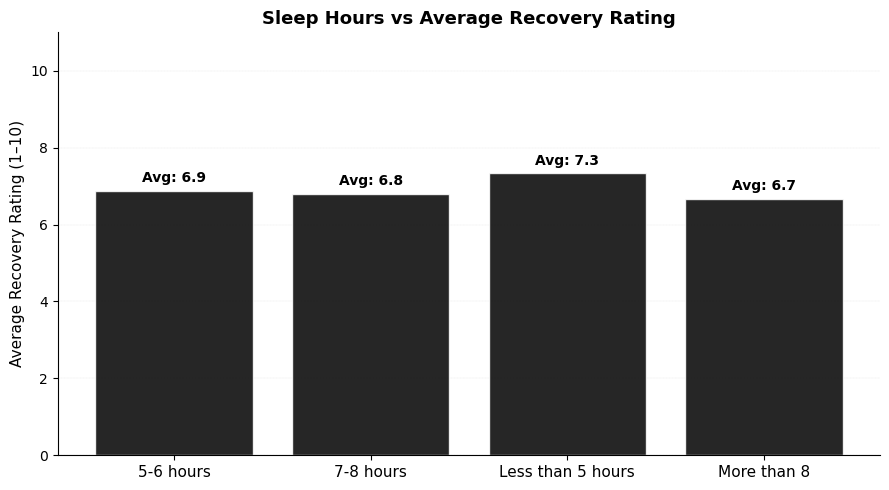

In [16]:
# Average recovery rating by sleep duration - bar chart with value labels

df_sleep = df[df['sleep_hours'] != '(Skip)']
sleep_order = sorted(df_sleep['sleep_hours'].dropna().unique().tolist())
avg_recovery = df_sleep.groupby('sleep_hours')['recovery_rating'].mean().reindex(sleep_order)
counts = df_sleep.groupby('sleep_hours')['recovery_rating'].count().reindex(sleep_order)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(range(len(avg_recovery)), avg_recovery.values,
             color='black', alpha=0.85, edgecolor='white')

for i, bar in enumerate(bars):
   ax.text(bar.get_x() + bar.get_width() / 2,
           bar.get_height() + 0.15,
           f'Avg: {bar.get_height():.1f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(avg_recovery)))
ax.set_xticklabels(avg_recovery.index, fontsize=11)
ax.set_ylabel('Average Recovery Rating (1–10)', fontsize=11)
ax.set_ylim(0, 11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.2, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

ax.set_title('Sleep Hours vs Average Recovery Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


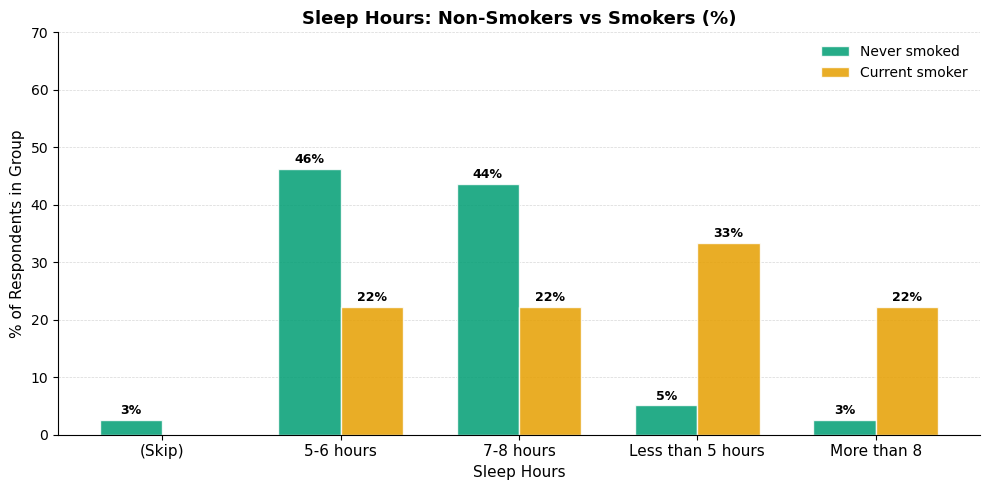

In [17]:
# Sleep duration distribution — Never smoked vs Current smoker

groups = ['Never smoked', 'Current smoker']
colors = {'Never smoked': '#009E73', 'Current smoker': '#E69F00'}

sleep_order = sorted(df['sleep_hours'].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(sleep_order))
width = 0.35

for i, grp in enumerate(groups):
    subset = df[df['smoking_status'] == grp]
    counts = subset['sleep_hours'].value_counts().reindex(sleep_order, fill_value=0)
    percentages = (counts / counts.sum() * 100).round(1)

    bars = ax.bar(x + i * width, percentages.values, width,
                  label=grp, color=colors[grp], alpha=0.85, edgecolor='white')

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{bar.get_height():.0f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')


# Shown as percentages to account for unequal group sizes

ax.set_xticks(x + width / 2)
ax.set_xticklabels(sleep_order, fontsize=11)
ax.set_ylabel('% of Respondents in Group', fontsize=11)
ax.set_xlabel('Sleep Hours', fontsize=11)
ax.set_ylim(0, 70)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Sleep Hours: Non-Smokers vs Smokers (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


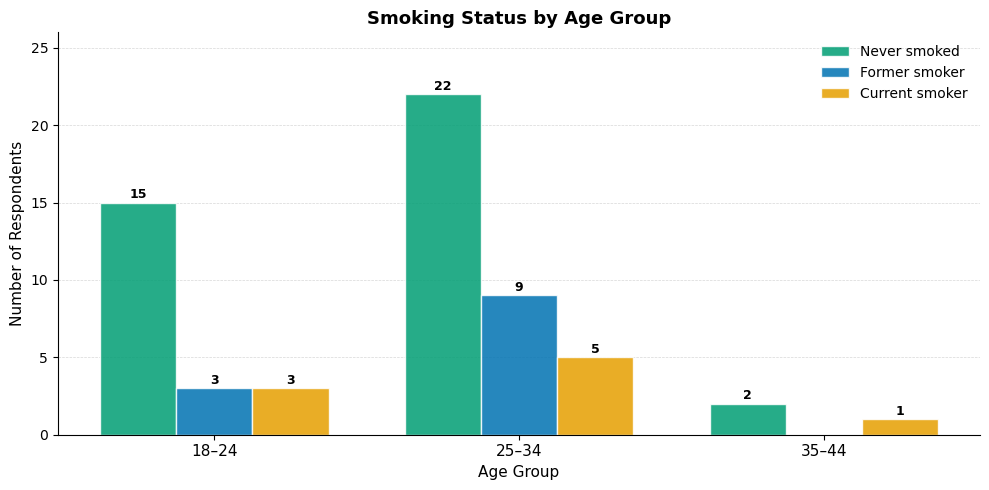

In [18]:
# Smoking status breakdown by age group

age_order = sorted(df['age_group'].dropna().unique().tolist())
smoking_groups = ['Never smoked', 'Former smoker', 'Current smoker']
colors = ['#009E73', '#0072B2', '#E69F00']

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(age_order))
width = 0.25

for i, (grp, color) in enumerate(zip(smoking_groups, colors)):
    subset = df[df['smoking_status'] == grp]
    counts = subset['age_group'].value_counts().reindex(age_order, fill_value=0)

    bars = ax.bar(x + i * width, counts.values, width,
                  label=grp, color=color, alpha=0.85, edgecolor='white')

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(age_order, fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylim(0, 26)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Smoking Status by Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


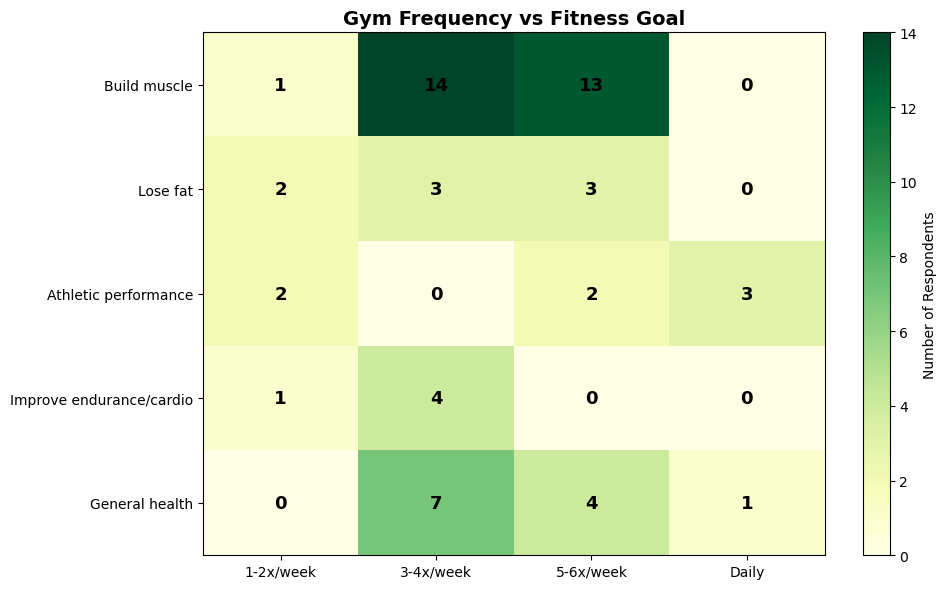

In [19]:
# Heatmap: gym frequency vs fitness goal

freq_order = ['1\u20132 times per week', '3\u20134 times per week', '5\u20136 times per week', 'Daily']
goal_order = ['Build muscle', 'Lose fat', 'Athletic performance', 'Improve endurance/cardio', 'General health']

cross = pd.crosstab(df['fitness_goal'], df['gym_frequency'])
cross = cross.reindex(index=goal_order, columns=freq_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(cross.values, cmap='YlGn', aspect='auto')

for i in range(len(goal_order)):
    for j in range(len(freq_order)):
        ax.text(j, i, str(cross.values[i, j]),
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='black')

# Darker cells indicate higher respondent count at that combination

ax.set_xticks(range(len(freq_order)))
ax.set_xticklabels(['1-2x/week', '3-4x/week', '5-6x/week', 'Daily'], fontsize=10)
ax.set_yticks(range(len(goal_order)))
ax.set_yticklabels(goal_order, fontsize=10)

ax.set_title('Gym Frequency vs Fitness Goal', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Number of Respondents')
plt.tight_layout()
plt.show()

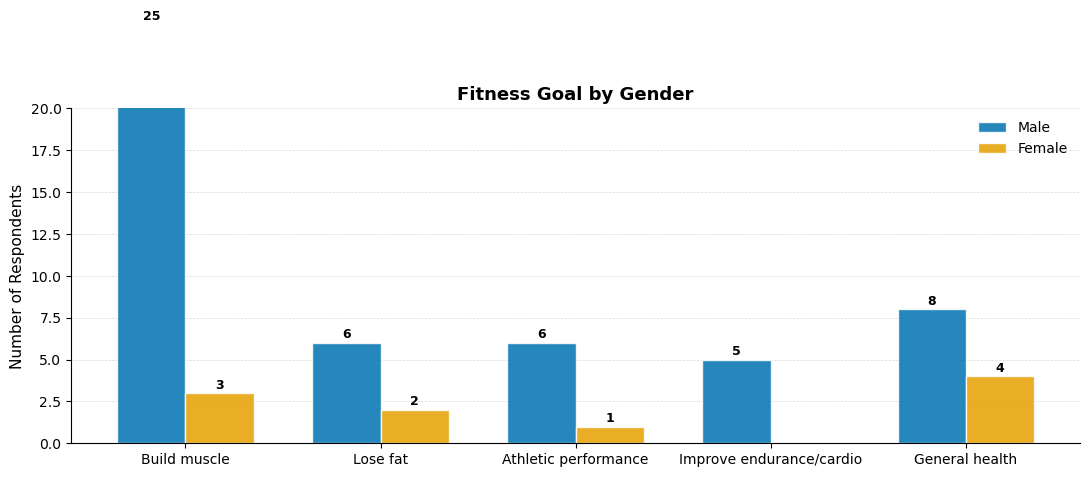

In [20]:
# Fitness goal breakdown by gender

gender_groups = df['gender'].dropna().unique().tolist()
goal_order = ['Build muscle', 'Lose fat', 'Athletic performance', 'Improve endurance/cardio', 'General health']
gender_colors = {'Male': '#0072B2', 'Female': '#E69F00'}

x = np.arange(len(goal_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

for i, grp in enumerate(gender_groups):
    subset = df[df['gender'] == grp]
    counts = subset['fitness_goal'].value_counts().reindex(goal_order, fill_value=0)
    bars = ax.bar(x + i * width, counts.values, width,
                  label=grp, color=gender_colors.get(grp, 'grey'),
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(goal_order, fontsize=10)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_ylim(0, 20)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Fitness Goal by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


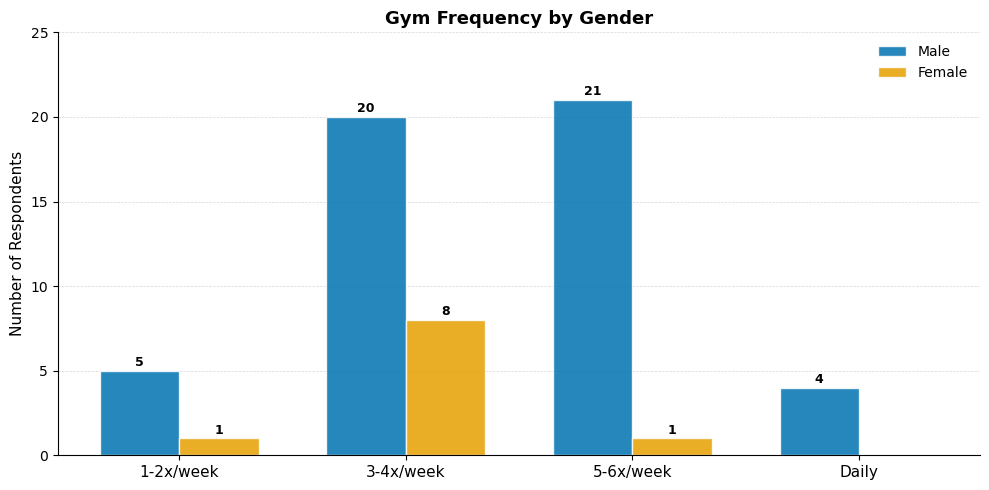

In [21]:
# Gym frequency breakdown by gender

freq_order = ['1\u20132 times per week', '3\u20134 times per week', '5\u20136 times per week', 'Daily']
freq_labels = ['1-2x/week', '3-4x/week', '5-6x/week', 'Daily']
gender_groups = df['gender'].dropna().unique().tolist()
gender_colors = {'Male': '#0072B2', 'Female': '#E69F00'}

x = np.arange(len(freq_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, grp in enumerate(gender_groups):
    subset = df[df['gender'] == grp]
    counts = subset['gym_frequency'].value_counts().reindex(freq_order, fill_value=0)
    bars = ax.bar(x + i * width, counts.values, width,
                  label=grp, color=gender_colors.get(grp, 'grey'),
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(freq_labels, fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_ylim(0, 25)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Gym Frequency by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


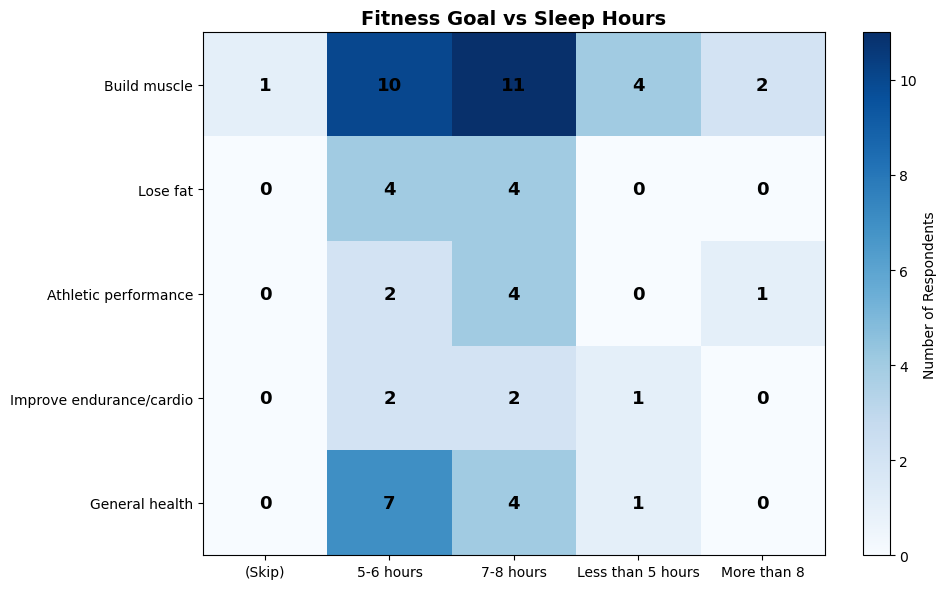

In [22]:
# Heatmap: fitness goal vs sleep hours

sleep_order = sorted(df['sleep_hours'].dropna().unique().tolist())
goal_order = ['Build muscle', 'Lose fat', 'Athletic performance', 'Improve endurance/cardio', 'General health']

cross = pd.crosstab(df['fitness_goal'], df['sleep_hours'])
cross = cross.reindex(index=goal_order, columns=sleep_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(cross.values, cmap='Blues', aspect='auto')

for i in range(len(goal_order)):
    for j in range(len(sleep_order)):
        ax.text(j, i, str(cross.values[i, j]),
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='black')

# Darker cells indicate higher respondent count at that combination

ax.set_xticks(range(len(sleep_order)))
ax.set_xticklabels(sleep_order, fontsize=10)
ax.set_yticks(range(len(goal_order)))
ax.set_yticklabels(goal_order, fontsize=10)

ax.set_title('Fitness Goal vs Sleep Hours', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Number of Respondents')
plt.tight_layout()
plt.show()


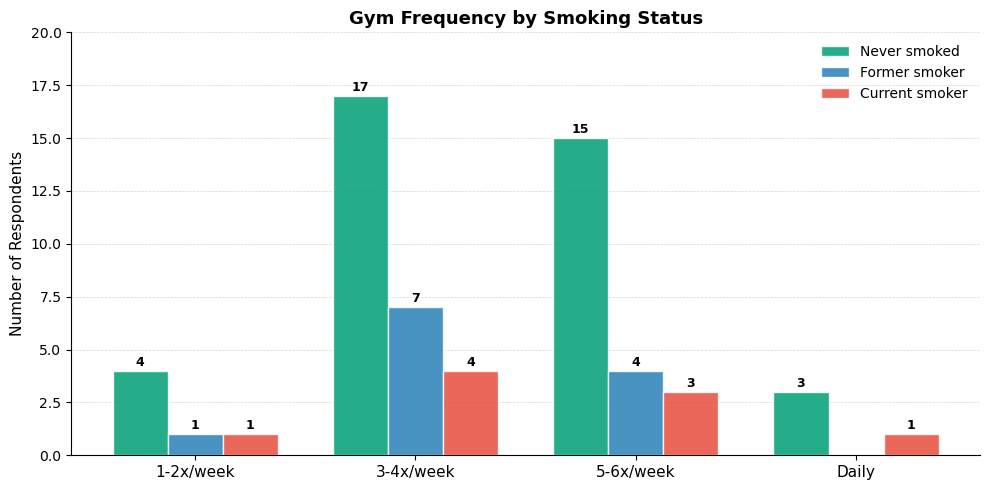

In [23]:
# Gym frequency breakdown by smoking status

freq_order = ['1\u20132 times per week', '3\u20134 times per week', '5\u20136 times per week', 'Daily']
freq_labels = ['1-2x/week', '3-4x/week', '5-6x/week', 'Daily']
smoking_groups = ['Never smoked', 'Former smoker', 'Current smoker']
colors = ['#009E73', '#2980B9', '#E74C3C']

x = np.arange(len(freq_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (grp, color) in enumerate(zip(smoking_groups, colors)):
    subset = df[df['smoking_status'] == grp]
    counts = subset['gym_frequency'].value_counts().reindex(freq_order, fill_value=0)
    bars = ax.bar(x + i * width, counts.values, width,
                  label=grp, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(freq_labels, fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_ylim(0, 20)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Gym Frequency by Smoking Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


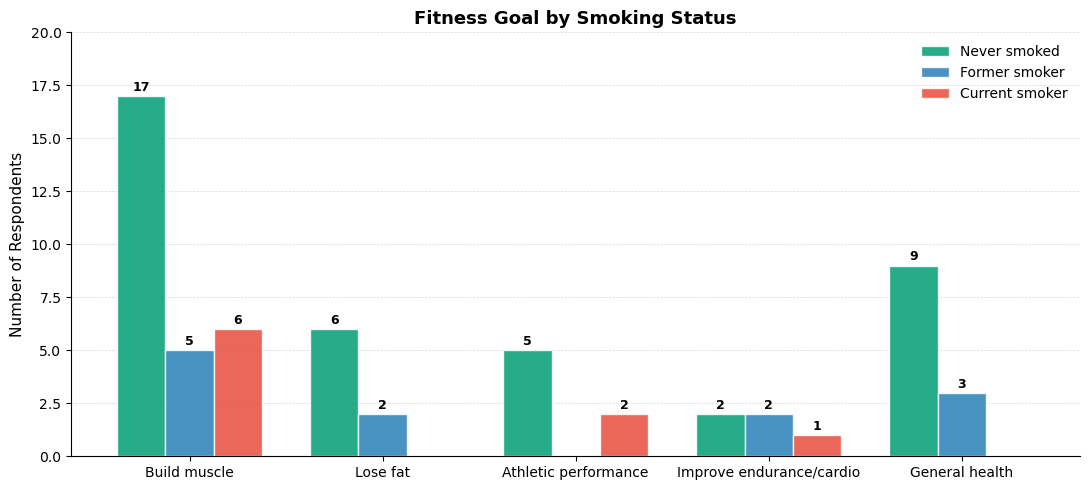

In [24]:
# Fitness goal breakdown by smoking status

goal_order = ['Build muscle', 'Lose fat', 'Athletic performance', 'Improve endurance/cardio', 'General health']
smoking_groups = ['Never smoked', 'Former smoker', 'Current smoker']
colors = ['#009E73', '#2980B9', '#E74C3C']

x = np.arange(len(goal_order))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (grp, color) in enumerate(zip(smoking_groups, colors)):
    subset = df[df['smoking_status'] == grp]
    counts = subset['fitness_goal'].value_counts().reindex(goal_order, fill_value=0)
    bars = ax.bar(x + i * width, counts.values, width,
                  label=grp, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(goal_order, fontsize=10)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_ylim(0, 20)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.set_title('Fitness Goal by Smoking Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


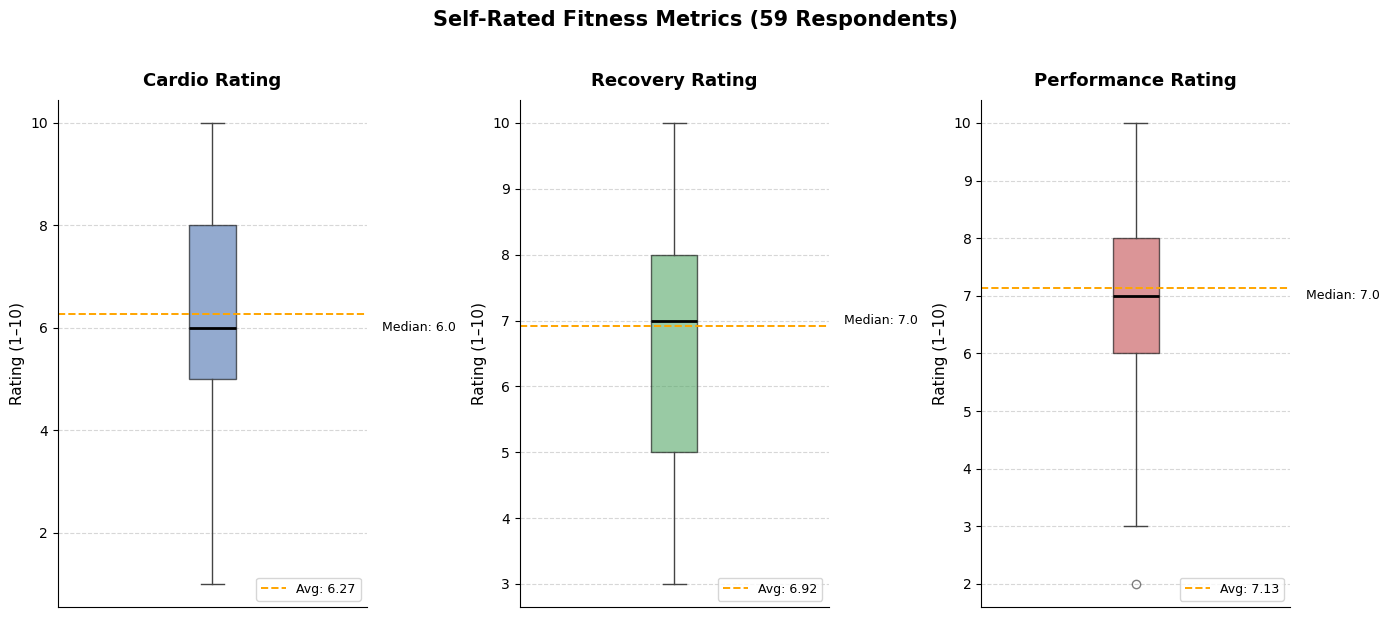

In [25]:
# Box plots: self-rated cardio, recovery, and performance across all respondents
# Orange dashed line shows average — black line inside box shows median

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

metrics = ['cardio_rating', 'recovery_rating', 'performance_rating']
titles = ['Cardio Rating', 'Recovery Rating', 'Performance Rating']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    data = df[metric].dropna()

    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.6),
        whiskerprops=dict(color='#444444'),
        capprops=dict(color='#444444'),
        flierprops=dict(marker='o', color=color, alpha=0.5)
    )
    
    avg = data.mean()
    median = data.median()

    ax.axhline(avg, color='orange', linestyle='--', linewidth=1.4, label=f'Avg: {avg:.2f}')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Rating (1–10)', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='lower right')

    ax.text(
        1.05, median,
        f'Median: {median:.1f}',
        transform=ax.get_yaxis_transform(),
        va='center', fontsize=9, color='black'
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle('Self-Rated Fitness Metrics (59 Respondents)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Findings

### 1. Demographics
The sample is male-dominated (49 males, 10 females), with the majority of respondents in the 25–34 and 18–24 age groups. This reflects a younger adult population typical of gym-going communities. The gender imbalance should be noted when interpreting any gender-disaggregated findings.

---

### 2. Gym Behaviour
Respondents targeting muscle gain are more likely to train 3–4 or 5–6 times per week, while those focused on weight loss show a wider spread of frequencies. General health respondents cluster in the mid-range (3–4 times per week), suggesting less structured training commitment. Build muscle is overwhelmingly the most common fitness goal (27 out of 59 respondents), confirming this is a highly motivated, goal-driven sample.

---

### 3. Smoking & Fitness
Current smokers consistently self-report lower cardio, recovery, and performance ratings compared to former smokers and never-smokers. The gap is most pronounced in cardio rating, consistent with smoking's direct impact on lung capacity. Former smokers rate higher than current smokers but slightly below never-smokers, suggesting partial fitness recovery after cessation. The majority of the respondents acknowledge that smoking negatively affects fitness performance, and most indicate they would consider quitting — showing self-awareness and readiness for behaviour change.

---

### 4. Sleep & Recovery
Respondents sleeping 7–8 hours report higher recovery ratings on average. Muscle gain respondents tend toward 7–8 hours of sleep, consistent with the role of sleep in recovery and hypertrophy. Current smokers are slightly overrepresented in the lower sleep bands (5–6 hours), suggesting a co-occurrence of lifestyle risk factors, though causality cannot be established from this cross-sectional data.

---

### 5. Overall Conclusion
Across 59 respondents, smoking status is the variable most strongly associated with lower self-rated fitness outcomes, particularly cardio performance. Sleep duration and gym frequency jointly support recovery and performance ratings. The sample is motivated and goal-oriented — findings have practical relevance for fitness programme design and health communication targeting young adult populations.

> **Limitations:** Data is self-reported and cross-sectional. Sample size (n = 59) limits statistical power. Gender and smoking status imbalances should be noted when interpreting subgroup comparisons.